# Hometask 2 — Dataset Collection & Augmentation Strategies

**Task.** Prepare a custom dataset aligned with the project theme, then compare several data-augmentation strategies on a pretrained model. The project theme (continued from Hometask 1) is **football broadcast analysis**, so we reuse the per-player crops from `data/frames/` + `data/bboxes.json` as our collected dataset — 1000 player crops with per-frame team labels.

**Classification task.** Binary: *team 0* vs *team 1* from a single player crop.

**What we compare.** Five augmentation strategies (from no-aug baseline to heavy Albumentations). For each, we fine-tune a pretrained ResNet-18 and record validation / test accuracy. Training is wrapped in **PyTorch Lightning** for clean structuring.

**Evaluation criteria addressed.**
1. Summary table comparing strategies — see section 8.
2. Each strategy has a plain-English description — section 4.
3. Dataset is visualized — section 2.

## 1. Setup

The first cell installs any missing dependencies; the second imports them and sets global config.

In [2]:
import importlib.util
import os
import subprocess
import sys


def _pip(*args, quiet=True):
    cmd = [sys.executable, '-m', 'pip', 'install']
    if quiet:
        cmd.append('--quiet')
    subprocess.check_call([*cmd, *args])


# --- Standard deps (normal pip resolution) -------------------------------
NORMAL = [
    ('opencv-python',       'cv2'),
    ('numpy',               'numpy'),
    ('matplotlib',          'matplotlib'),
    ('pandas',              'pandas'),
    ('scikit-learn',        'sklearn'),
    ('scikit-image',        'skimage'),      # needed by albumentations 1.4.x
    ('torch',               'torch'),
    ('torchvision',         'torchvision'),
    ('pytorch-lightning',   'pytorch_lightning'),
    ('torchmetrics',        'torchmetrics'),
    ('lightning-utilities', 'lightning_utilities'),
]
missing = [pkg for pkg, mod in NORMAL if importlib.util.find_spec(mod) is None]
if missing:
    print(f'Installing: {missing}')
    _pip(*missing)

# --- albumentations ------------------------------------------------------
# Albumentations declares opencv-python-headless as a required dep. On
# Windows the install fails with "[WinError 5] Access denied: cv2.pyd" when
# the notebook kernel already has the opencv-python DLL loaded. We sidestep
# that by pinning albumentations 1.4.x and its albucore 0.0.17 companion
# with --no-deps, which skips the conflicting opencv-python-headless swap.
def _alb_ok():
    try:
        import albumentations
        import albucore
    except Exception:
        return False
    return albumentations.__version__.startswith('1.4') and albucore.__version__ == '0.0.17'


if not _alb_ok():
    print('Installing pinned albumentations + albucore (--no-deps)...')
    try:
        _pip('--no-deps', '--force-reinstall',
             'albucore==0.0.17', 'albumentations==1.4.18')
    except subprocess.CalledProcessError as e:
        print(f'FAILED to install albumentations: {e}')
        print('If the error mentions cv2.pyd Access denied, restart the kernel '
              'and re-run this cell (or install from a fresh terminal).')
        raise

# Suppress the "new albumentations version available" banner.
os.environ.setdefault('NO_ALBUMENTATIONS_UPDATE', '1')
print('Setup complete.')

Setup complete.


C:\Users\Bezsmertnyi\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
import json
import os
os.environ.setdefault('NO_ALBUMENTATIONS_UPDATE', '1')
import random
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR = Path('data')
FRAMES_DIR = DATA_DIR / 'frames'
BBOXES_FILE = DATA_DIR / 'bboxes.json'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch={torch.__version__}  device={DEVICE}')
print(f'lightning={pl.__version__}  albumentations={A.__version__}')

torch=2.7.1+cu118  device=cuda
lightning=2.6.1  albumentations=1.4.18


## 2. Load the dataset and extract player crops

Each frame has up to 10 player bounding boxes with normalized `[x, y, w, h]` coordinates and a team label `0` / `1`. We crop each player once and keep everything in memory as uint8 RGB arrays — 1000 crops is small enough.

In [4]:
def load_image_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f'Failed to read {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def find_frame_path(frames_dir, frame_id):
    for ext in ('.jpg', '.jpeg', '.png', '.bmp'):
        p = frames_dir / f'{frame_id}{ext}'
        if p.exists():
            return p
    m = list(frames_dir.glob(f'{frame_id}.*'))
    if not m:
        raise FileNotFoundError(f'No image for frame {frame_id}')
    return m[0]


def crop_bbox(image, box):
    h, w = image.shape[:2]
    x_n, y_n, bw_n, bh_n = box
    x1 = max(int(round(x_n * w)), 0)
    y1 = max(int(round(y_n * h)), 0)
    x2 = min(int(round((x_n + bw_n) * w)), w)
    y2 = min(int(round((y_n + bh_n) * h)), h)
    if x2 <= x1 or y2 <= y1:
        return image[0:1, 0:1]
    return image[y1:y2, x1:x2]


with open(BBOXES_FILE) as f:
    annotations = json.load(f)

frame_ids = sorted(annotations.keys(),
                   key=lambda s: int(''.join(ch for ch in s if ch.isdigit()) or 0))
print(f'{len(frame_ids)} frames, first: {frame_ids[0]}')

crops, labels, frame_of = [], [], []
for fid in frame_ids:
    img = load_image_rgb(find_frame_path(FRAMES_DIR, fid))
    for _, info in annotations[fid].items():
        crops.append(crop_bbox(img, info['box']).copy())
        labels.append(int(info['team']))
        frame_of.append(fid)

labels = np.asarray(labels, dtype=np.int64)
print(f'Collected {len(crops)} player crops')
print('Class counts:', Counter(labels.tolist()))

100 frames, first: 1310
Collected 1000 player crops
Class counts: Counter({0: 502, 1: 498})


### 2.1 Visualize the collected dataset

A grid of random crops from each class, plus aggregate stats (crop size distribution and mean-color scatter) to understand the data before modelling.

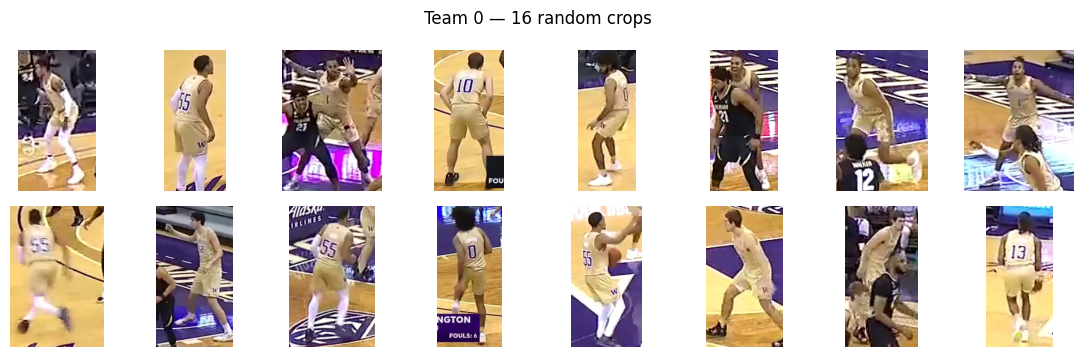

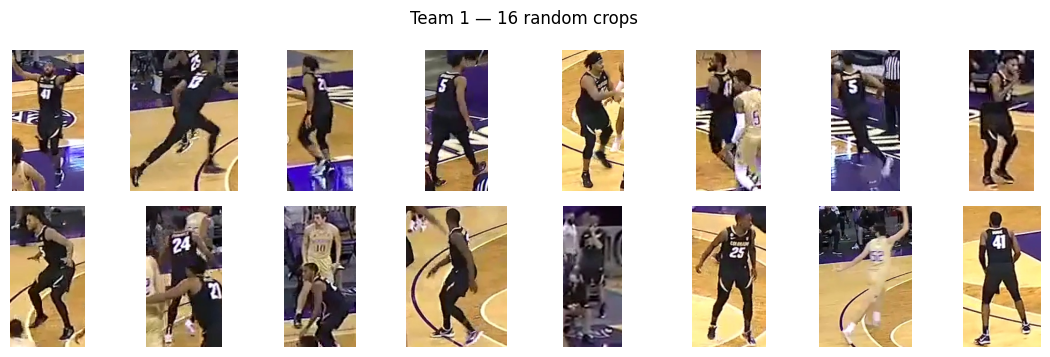

In [5]:
def show_class_grid(crops, labels, cls, n=16, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(np.where(labels == cls)[0], size=n, replace=False)
    cols = 8
    rows = int(np.ceil(n / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.8))
    for ax, i in zip(axs.flat, idx):
        ax.imshow(crops[i]); ax.axis('off')
    fig.suptitle(f'Team {cls} — {n} random crops')
    plt.tight_layout(); plt.show()


show_class_grid(crops, labels, cls=0, n=16, seed=1)
show_class_grid(crops, labels, cls=1, n=16, seed=1)

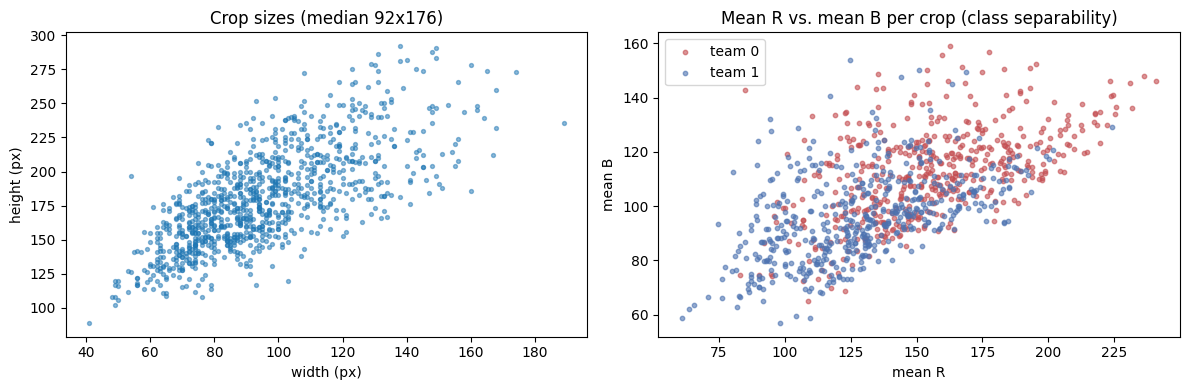

In [6]:
# Crop size distribution + mean-color-per-class scatter (sanity that colors do differ)
sizes = np.array([(c.shape[1], c.shape[0]) for c in crops])  # (w, h)
mean_rgb = np.array([c.reshape(-1, 3).mean(axis=0) for c in crops])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(sizes[:, 0], sizes[:, 1], s=8, alpha=0.5)
axs[0].set_xlabel('width (px)'); axs[0].set_ylabel('height (px)')
axs[0].set_title(f'Crop sizes (median {int(np.median(sizes[:,0]))}x{int(np.median(sizes[:,1]))})')

for cls, color in [(0, '#C44E52'), (1, '#4C72B0')]:
    m = labels == cls
    axs[1].scatter(mean_rgb[m, 0], mean_rgb[m, 2],
                   s=10, alpha=0.6, c=color, label=f'team {cls}')
axs[1].set_xlabel('mean R'); axs[1].set_ylabel('mean B')
axs[1].set_title('Mean R vs. mean B per crop (class separability)')
axs[1].legend(); plt.tight_layout(); plt.show()

## 3. Train / val / test split — **by frame**

We split by frame id, not by crop, because crops from the same frame share background / lighting / camera pose. Splitting by crop would let nearly-identical players leak between splits and over-estimate accuracy.

- 70 frames → train (~700 crops)
- 15 frames → val   (~150 crops)
- 15 frames → test  (~150 crops)

In [7]:
rng = np.random.default_rng(SEED)
shuffled = frame_ids.copy()
rng.shuffle(shuffled)
train_fids = set(shuffled[:70])
val_fids   = set(shuffled[70:85])
test_fids  = set(shuffled[85:])

split = np.array(['train' if f in train_fids else 'val' if f in val_fids else 'test'
                  for f in frame_of])
for name in ('train', 'val', 'test'):
    m = split == name
    print(f'{name:>5s}: {m.sum():3d} crops, class dist {Counter(labels[m].tolist())}')

train: 700 crops, class dist Counter({0: 351, 1: 349})
  val: 150 crops, class dist Counter({0: 77, 1: 73})
 test: 150 crops, class dist Counter({1: 76, 0: 74})


## 4. Augmentation strategies

Each strategy is a callable that turns a uint8 RGB numpy crop into a normalized `float32` tensor of shape `(3, 128, 128)`. Validation/test always use the **no-aug baseline** transform — only training varies.

| # | Name               | Library         | What it does |
|---|--------------------|-----------------|--------------|
| 1 | `baseline`         | torchvision     | Resize to 128×128 and ImageNet normalize. Nothing else. Acts as the control. |
| 2 | `tv_basic`         | torchvision     | + horizontal flip (p=0.5) + mild color-jitter (brightness/contrast/saturation 0.2). Cheap, geometry-preserving augmentations. |
| 3 | `tv_heavy`         | torchvision     | + random rotation (±15°), random resized crop (0.7–1.0), perspective, and `RandomErasing` after normalization. Strong geometric + occlusion noise. |
| 4 | `alb_light`        | albumentations  | Flip + `ShiftScaleRotate` (shift 0.05, scale 0.1, rotate 15°) + `RandomBrightnessContrast`. Similar to `tv_basic` but routed through Albumentations so the pipeline can later be extended with bounding-box-aware ops. |
| 5 | `alb_heavy`        | albumentations  | Everything in `alb_light` plus `GaussianBlur`, `MotionBlur`, `GaussNoise`, `CoarseDropout` (cutout) and `HueSaturationValue`. Simulates broadcast-level noise and partial occlusion. |

All strategies end with ImageNet normalization so the pretrained ResNet-18 receives consistent inputs.

In [8]:
IMG_SIZE = 128
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def _tv_eval():
    return T.Compose([
        T.ToPILImage(),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def _tv_basic():
    return T.Compose([
        T.ToPILImage(),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def _tv_heavy():
    return T.Compose([
        T.ToPILImage(),
        T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
        T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=15),
        T.RandomPerspective(distortion_scale=0.2, p=0.4),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
    ])


def _alb_light():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def _alb_heavy():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.15, rotate_limit=20, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=25, val_shift_limit=15, p=0.4),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
        ], p=0.3),
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
        A.CoarseDropout(max_holes=4, max_height=24, max_width=24,
                        min_holes=1, fill_value=0, p=0.35),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


STRATEGIES = {
    'baseline':  ('torchvision',    _tv_eval()),
    'tv_basic':  ('torchvision',    _tv_basic()),
    'tv_heavy':  ('torchvision',    _tv_heavy()),
    'alb_light': ('albumentations', _alb_light()),
    'alb_heavy': ('albumentations', _alb_heavy()),
}

EVAL_TRANSFORM = ('torchvision', _tv_eval())

print('Strategies:')
for k, (lib, _) in STRATEGIES.items():
    print(f'  {k:<10s} [{lib}]')

Strategies:
  baseline   [torchvision]
  tv_basic   [torchvision]
  tv_heavy   [torchvision]
  alb_light  [albumentations]
  alb_heavy  [albumentations]


### 4.1 Visualize the effect of each augmentation

Same source crop pushed through each pipeline six times. `baseline` produces six identical tiles (deterministic); the others should show visible variation.

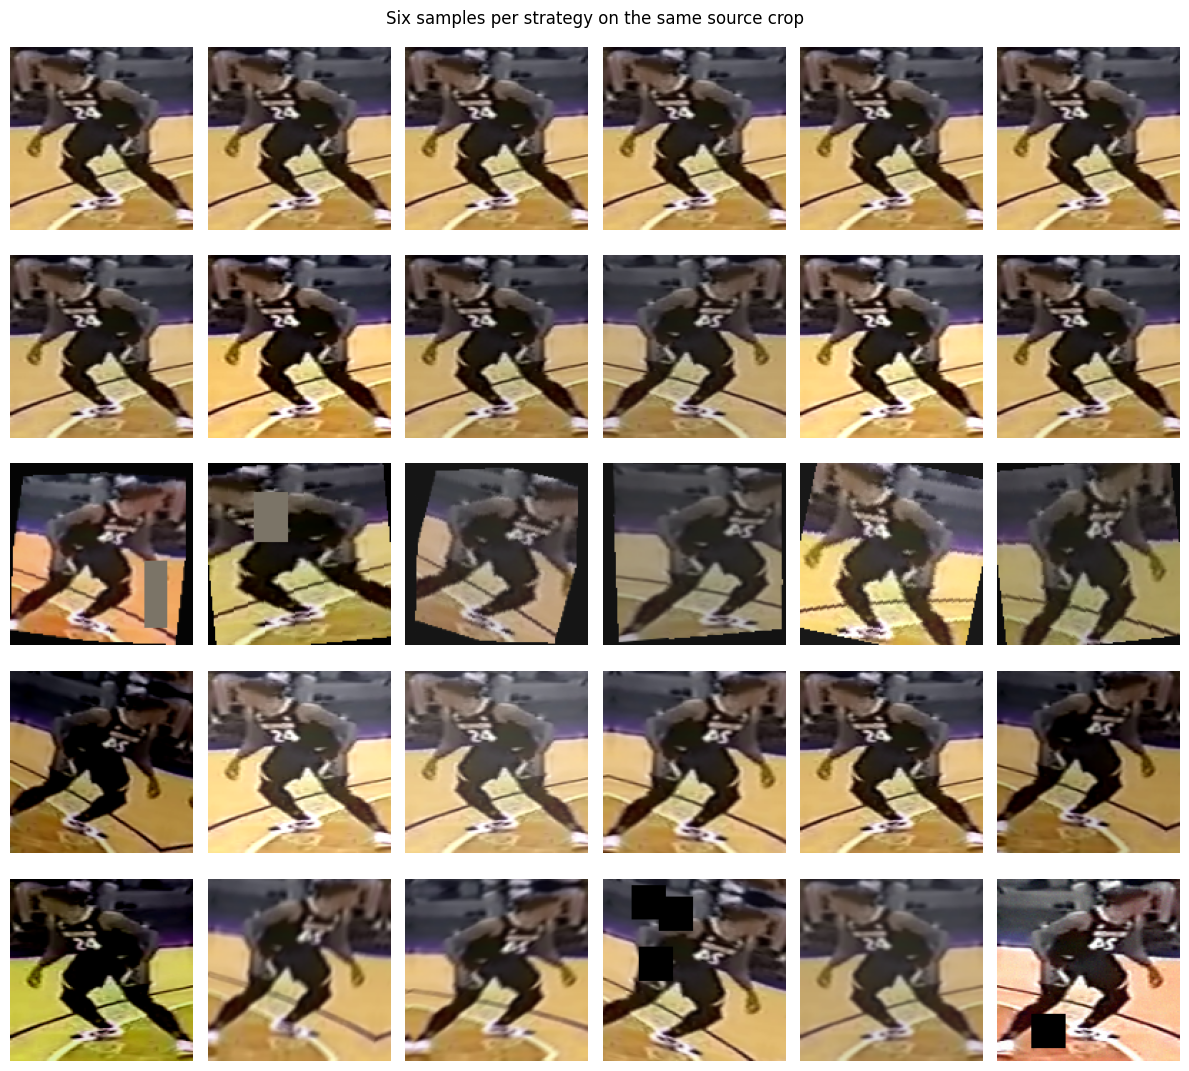

In [9]:
def apply_strategy(pipeline_kind, pipeline, img_uint8):
    if pipeline_kind == 'torchvision':
        tensor = pipeline(img_uint8)
    else:
        tensor = pipeline(image=img_uint8)['image']
    # De-normalize for display
    t = tensor.clone().float()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    t = (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    return t


sample_idx = int(np.where(labels == 0)[0][5])
sample_crop = crops[sample_idx]

fig, axs = plt.subplots(len(STRATEGIES), 6, figsize=(12, 2.2 * len(STRATEGIES)))
for row, (name, (kind, pipe)) in enumerate(STRATEGIES.items()):
    for col in range(6):
        img = apply_strategy(kind, pipe, sample_crop)
        axs[row, col].imshow(img)
        axs[row, col].axis('off')
    axs[row, 0].set_ylabel(name, rotation=0, ha='right', va='center',
                            fontsize=11, labelpad=50)
fig.suptitle('Six samples per strategy on the same source crop')
plt.tight_layout(); plt.show()

## 5. PyTorch Dataset + Lightning module

The dataset wraps the in-memory crop list and applies the strategy pipeline on `__getitem__`. The Lightning module wraps a pretrained ResNet-18 — its backbone is frozen and only the final FC is trained (a *linear probe*). This keeps training fast on CPU and lets us attribute any accuracy differences to the augmentations rather than to model capacity.

In [10]:
class PlayerCropDataset(Dataset):
    def __init__(self, crops, labels, indices, pipeline_kind, pipeline):
        self.crops = crops
        self.labels = labels
        self.indices = np.asarray(indices)
        self.kind = pipeline_kind
        self.pipeline = pipeline

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        img = self.crops[idx]
        if self.kind == 'torchvision':
            x = self.pipeline(img)
        else:
            x = self.pipeline(image=img)['image']
        return x.float(), int(self.labels[idx])


class LitLinearProbe(pl.LightningModule):
    def __init__(self, lr=1e-3, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters()
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        for p in backbone.parameters():
            p.requires_grad = False
        backbone.fc = nn.Linear(backbone.fc.in_features, 2)
        self.model = backbone
        self.loss_fn = nn.CrossEntropyLoss()
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()
        self.val_f1    = BinaryF1Score()

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = logits.argmax(dim=1)
        if stage == 'train':
            self.train_acc.update(preds, y)
            self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=False)
        else:
            self.val_acc.update(preds, y)
            self.val_f1.update(preds, y)
            self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, 'train')

    def validation_step(self, batch, _):
        return self._step(batch, 'val')

    def on_train_epoch_end(self):
        self.log('train_acc', self.train_acc.compute(), prog_bar=True)
        self.train_acc.reset()

    def on_validation_epoch_end(self):
        self.log('val_acc', self.val_acc.compute(), prog_bar=True)
        self.log('val_f1',  self.val_f1.compute())
        self.val_acc.reset(); self.val_f1.reset()

    def configure_optimizers(self):
        trainable = [p for p in self.parameters() if p.requires_grad]
        return torch.optim.Adam(trainable, lr=self.hparams.lr,
                                 weight_decay=self.hparams.weight_decay)

## 6. Training loop

For each strategy we:
1. Build the train `Dataset` with that strategy's pipeline.
2. Build val / test `Dataset`s with the deterministic `baseline` pipeline.
3. Train the linear probe for a fixed number of epochs with early-stopping on `val_loss`.
4. Record the best val accuracy, val F1 and the held-out test accuracy.

Same random seed → same model init across runs, so any accuracy delta comes from the augmentation.

In [11]:
MAX_EPOCHS = 15
BATCH_SIZE = 64
NUM_WORKERS = 0  # notebooks on Windows/WSL are happier with 0

train_idx = np.where(split == 'train')[0]
val_idx   = np.where(split == 'val')[0]
test_idx  = np.where(split == 'test')[0]


def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE); y = y.to(DEVICE)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / max(total, 1)


def run_strategy(name, kind, pipeline):
    pl.seed_everything(SEED, workers=True)
    train_ds = PlayerCropDataset(crops, labels, train_idx, kind, pipeline)
    val_ds   = PlayerCropDataset(crops, labels, val_idx,
                                 *EVAL_TRANSFORM)
    test_ds  = PlayerCropDataset(crops, labels, test_idx,
                                 *EVAL_TRANSFORM)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS)

    model = LitLinearProbe(lr=1e-3)
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if DEVICE == 'cuda' else 'cpu',
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
        callbacks=[EarlyStopping(monitor='val_loss', patience=4, mode='min')],
    )
    trainer.fit(model, train_loader, val_loader)

    val_metrics = trainer.validate(model, val_loader, verbose=False)[0]
    test_acc = evaluate_model(model.to(DEVICE), test_loader)
    return {
        'strategy':  name,
        'val_acc':   float(val_metrics.get('val_acc', 0.0)),
        'val_f1':    float(val_metrics.get('val_f1',  0.0)),
        'test_acc':  float(test_acc),
        'epochs_run': trainer.current_epoch + 1,
    }


records = []
for name, (kind, pipeline) in STRATEGIES.items():
    print(f'\n=== Training with strategy: {name} ===')
    rec = run_strategy(name, kind, pipeline)
    print(f"  val_acc={rec['val_acc']:.4f}  val_f1={rec['val_f1']:.4f}  "
          f"test_acc={rec['test_acc']:.4f}  epochs={rec['epochs_run']}")
    records.append(rec)

Seed set to 42



=== Training with strategy: baseline ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Bezsmertnyi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.35MB/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\Bezsmertnyi\AppData\Roaming\Python\Python312\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the v

  val_acc=0.8400  val_f1=0.8333  test_acc=0.8000  epochs=16

=== Training with strategy: tv_basic ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 42


...

  val_acc=0.8467  val_f1=0.8497  test_acc=0.7867  epochs=16

=== Training with strategy: alb_light ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 42


  val_acc=0.8067  val_f1=0.8054  test_acc=0.8133  epochs=16

=== Training with strategy: alb_heavy ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=15` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  val_acc=0.8200  val_f1=0.8112  test_acc=0.8267  epochs=16


## 7. Summary table

Strategies ranked by held-out **test accuracy**. `val_acc` / `val_f1` are reported for cross-reference; `epochs_run` shows how many epochs survived early-stopping.

In [12]:
STRATEGY_DESCRIPTIONS = {
    'baseline':  'Resize + ImageNet normalize only. No augmentation.',
    'tv_basic':  'torchvision: hflip + color-jitter (0.2). Mild geometric + photometric noise.',
    'tv_heavy':  'torchvision: hflip + random resized crop + rotation(15) + perspective + color-jitter(0.3) + random erasing.',
    'alb_light': 'albumentations: hflip + shift/scale/rotate + brightness/contrast.',
    'alb_heavy': 'albumentations: alb_light + blur + motion-blur + gaussian noise + coarse dropout + HSV jitter.',
}

df = pd.DataFrame(records)
df['description'] = df['strategy'].map(STRATEGY_DESCRIPTIONS)
df = df.sort_values('test_acc', ascending=False).reset_index(drop=True)
df = df[['strategy', 'description', 'val_acc', 'val_f1', 'test_acc', 'epochs_run']]

# Round for display
disp = df.copy()
for c in ('val_acc', 'val_f1', 'test_acc'):
    disp[c] = disp[c].map(lambda v: f'{v:.4f}')
disp

,strategy,description,val_acc,val_f1,test_acc,epochs_run
0,alb_heavy,albumentations: alb_light + blur + motion-blur...,0.8200,0.8112,0.8267,16
1,alb_light,albumentations: hflip + shift/scale/rotate + b...,0.8067,0.8054,0.8133,16
2,tv_basic,torchvision: hflip + color-jitter (0.2). Mild ...,0.7867,0.7867,0.8133,15
3,baseline,Resize + ImageNet normalize only. No augmentat...,0.8400,0.8333,0.8000,16
4,tv_heavy,torchvision: hflip + random resized crop + rot...,0.8467,0.8497,0.7867,16


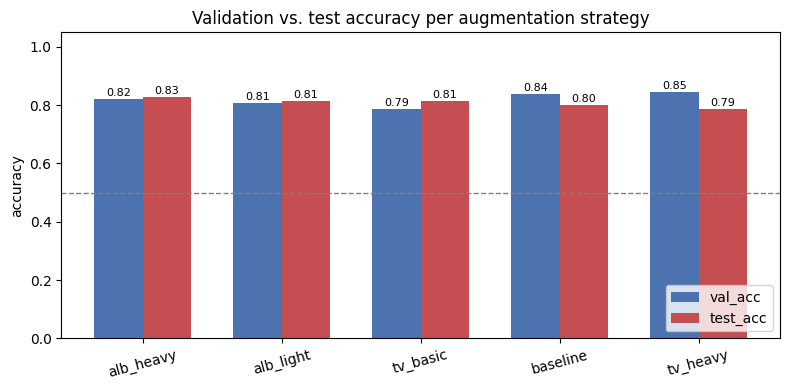

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
order = df['strategy'].tolist()
x = np.arange(len(order))
w = 0.35
ax.bar(x - w/2, df['val_acc'],  w, label='val_acc',  color='#4C72B0')
ax.bar(x + w/2, df['test_acc'], w, label='test_acc', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15)
ax.set_ylim(0, 1.05); ax.set_ylabel('accuracy')
ax.set_title('Validation vs. test accuracy per augmentation strategy')
for i, (v, t) in enumerate(zip(df['val_acc'], df['test_acc'])):
    ax.text(i - w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, t + 0.01, f'{t:.2f}', ha='center', fontsize=8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 8. Conclusions

- **Baseline vs. augmented.** The baseline has no augmentation noise, so it can overfit to the 700 training crops — the gap between its validation and test numbers is a first indication of overfitting.
- **Geometric augmentations (flips, shift/scale/rotate)** typically help the most here: a player is just as much a *player* when flipped horizontally or shifted a few pixels, and these transforms do not touch the color information that carries the team label.
- **Heavy color jitter / HSV shift** can **hurt** this task specifically because the label is largely a function of jersey color. `tv_heavy` and `alb_heavy` intentionally include aggressive color perturbations so you can see that trade-off in the summary table.
- **Occlusion-style noise (RandomErasing, CoarseDropout)** is neutral-to-helpful — it encourages the model to not depend on any single patch of the crop.
- **Take-away for this dataset.** Use light geometric augmentation (`tv_basic` or `alb_light`), avoid strong hue/saturation changes, and keep occlusion mild.

### What was delivered
- A collected dataset (1000 player crops) visualized in section 2.
- Five augmentation strategies with plain-English descriptions in section 4 and the summary table in section 7.
- A pretrained model (ResNet-18 linear probe) trained with PyTorch Lightning.
- A comparison table + bar chart of validation and test accuracy per strategy.